# 04 — Same client, new science: the Gaia HRD

Mini-project 1: reproduce the Gaia DR2 observational **Hertzsprung–Russell
diagram** of the solar neighbourhood — Fig. 5c of Gaia Collaboration,
Babusiaux et al. (2018), [A&A 616, A10](https://arxiv.org/abs/1804.09378):
the 212,728 stars within 100 pc.

The point of this notebook is the one the whole tutorial builds to:
**not a single line of agent code changes.** The same lead/worker graph that
compared power spectra in `02_` now does stellar astrophysics, because the
science lives in a different MCP server —
[`gaia-mcp-server`](https://github.com/HEP-KE/gaia-mcp-server) — and the only
thing we swap is the server config.

## Connect to the Gaia server

Over stdio the client launches the server itself — clone
`gaia-mcp-server` next to this repo. (A terminal server over
streamable-http works exactly as in `02_`: run
`python -m mcp_server --transport streamable-http --port 8000` from the
`gaia-mcp-server` directory and point the config at
`http://127.0.0.1:8000/mcp`.)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from dotenv import load_dotenv

load_dotenv(Path.cwd().parent / ".env")

OUTPUT_DIR = str((Path.cwd().parent / "agent-output").resolve())
GAIA_REPO = str((Path.cwd().parent.parent / "gaia-mcp-server").resolve())

from agents import build_graph, load_tools, make_llm, new_run

GAIA_CONFIG = {
    "gaia": {
        "transport": "stdio",
        "command": sys.executable,
        "args": ["-m", "mcp_server", "--transport", "stdio"],
        "cwd": GAIA_REPO,
    }
}

tools = await load_tools(GAIA_CONFIG)
for t in tools:
    print(f"{t.name:28s} {t.description.strip().splitlines()[0]}")

fetch_gaia_sample            Fetch the Gaia DR2 solar-neighbourhood sample and write it to a CSV.
apply_quality_filters        Apply the Babusiaux et al. (2018) quality filters to a Gaia sample CSV.
compute_absolute_magnitudes  Convert apparent G magnitudes to absolute using inverted parallaxes.
plot_cmd                     Draw the density colour-magnitude diagram (observational HRD).
compare_distance_shells      Draw side-by-side HRDs for nested distance shells (full Fig. 5).


## Build the graph — unchanged

Groq backend here to spare the Gemini daily quota (`make_llm()` uses Gemini
identically). Same two roles, same routing, no extras.

In [2]:
llm = make_llm("groq")
graph = build_graph(llm, tools)

## The task

Written to demand the mini-project deliverables: the density diagram, the
quality filters *with justifications*, and the star-count comparison with
the published figure.

In [3]:
TASK = f"""Reproduce the Gaia DR2 Hertzsprung-Russell diagram of the solar
neighbourhood (Babusiaux et al. 2018, Fig. 5c):

1. Fetch the Gaia 100 pc sample with source="bundled".
2. Apply the published quality filters (default settings).
3. Compute absolute magnitudes and draw the density colour-magnitude diagram.
4. Also draw the 25/50/100 pc distance-shell comparison.

Save all files to {OUTPUT_DIR}. In your final report include:
- the filtered star count compared with the published 212,728;
- every quality filter applied, each with its one-line justification
  (the filter tool returns these in its metadata);
- which features are visible: main sequence, binary sequence, red clump,
  white dwarf sequence."""

initial_state = new_run(TASK)

async for update in graph.astream(initial_state, stream_mode="updates"):
    for node, delta in update.items():
        print(f"=== {node} " + "=" * (60 - len(node)))
        if "plan" in delta:
            for step in delta["plan"]:
                print(f"  plan {step['id']}: {step['description']}")
        elif "final_report" in delta:
            final_report = delta["final_report"]
            print("  report ready")
        else:
            print(f"  {delta['step_results'][-1]}")

=== lead ========================================================
  plan 1: Use **fetch_gaia_sample** to download the Gaia DR2 solar‑neighbourhood (100 pc) dataset with `source="bundled"` and write the CSV to `/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_100pc_raw.csv`.
  plan 2: Run **apply_quality_filters** on the CSV from step 1, applying the Babusiaux et al. (2018) quality cuts (default settings). Save the filtered catalogue to `/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_100pc_filtered.csv`. The tool will also return metadata listing each filter and a one‑line justification.
  plan 3: Execute **compute_absolute_magnitudes** on the filtered CSV from step 2 to convert apparent G magnitudes to absolute magnitudes using inverted parallaxes. Output the enriched table to `/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_100pc_absmag.csv`.
  plan 4: Call **plot_cmd** with the absolute‑magnitude file from ste

=== worker ======================================================
  Fetched the Gaia DR2 100 pc sample (parallax ≥ 10 mas, parallax SNR > 10) from the bundled data and saved it to **/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_sample.csv** (439,019 rows). This file will be used as the raw dataset for the subsequent filtering steps.


=== worker ======================================================
  Applied the Babusiaux et al. (2018) quality cuts (default settings) to the 100 pc sample, retaining **212 728** stars—the exact published count. The filtered catalogue was written to  

**/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_sample_clean.csv**  

(and can be renamed to the requested `gaia_100pc_filtered.csv` if needed). The metadata includes each filter’s removal count and one‑line justification.


=== worker ======================================================
  The absolute‑magnitude table was created successfully; the CSV **/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_cmd.csv** contains the 212 728 stars with columns `bp_rp` and `abs_g_mag` (M_G).


=== worker ======================================================
  The density colour‑magnitude diagram was created and saved as  

**/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_cmd_hrd.png** (the tool writes the file with this name in the requested output directory).

**Report**

- **Filtered star count:** 212 728 stars remain after quality filtering – exactly the number reported in Babusiaux et al. (2018) Fig. 5c.  
- **Quality filters applied (with one‑line justifications):**  

  1. **G‑band flux SNR > 50** – “G‑band flux SNR > 50: keeps G photometry good to ~2%.”  
  2. **BP & RP flux SNR > 20** – “BP and RP flux SNR > 20: keeps the colour good to ~5%.”  
  3. **Photometric excess‑factor cut** – “1.0 + 0.015(BP‑RP)² < E < 1.3 + 0.06(BP‑RP)²: removes sources whose BP/RP flux is contaminated by neighbours or background (blends); without it a spurious plume crosses the diagram.”  
  4. **Astrometric quality cut** – “visibility_periods_used > 8 and unit w

=== worker ======================================================
  The side‑by‑side colour‑magnitude diagram for the 25 pc, 50 pc, and 100 pc shells has been generated and saved as  

**/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/gaia_cmd_shells.png**.  

(These three panels reproduce Fig. 5 of Babusiaux et al. 2018, showing the same main‑sequence, binary, red‑clump and white‑dwarf features as the full 100 pc HRD.)


=== lead ========================================================
  report ready


In [4]:
from IPython.display import Markdown

Markdown(final_report)

## Gaia DR2 Solar‑Neighbourhood HR Diagram – Summary Report  

**Goal** – Re‑create Fig. 5c of Babusiaux et al. (2018) using the Gaia DR2 100 pc sample, apply the published quality cuts, and visualise the colour‑magnitude diagram (CMD) for the full 100 pc volume plus 25 pc, 50 pc and 100 pc distance shells.

### What was done
1. **Data acquisition** – Downloaded the bundled Gaia DR2 catalogue limited to stars with parallax ≥ 10 mas and parallax SNR > 10 (≈ 439 k rows).  
2. **Quality filtering** – Applied the Babusiaux et al. (2018) cuts (default settings). Exactly **212 728** stars survived, matching the published count.  
3. **Absolute magnitudes** – Computed \(M_G = G + 5\log_{10}(\varpi/1000) + 5\) and the colour \(BP-RP\) for every retained source.  
4. **CMD visualisation** – Produced a density‑coloured HR diagram for the 100 pc sample and a three‑panel comparison for the 25 pc, 50 pc and 100 pc shells.  

### Quality filters (one‑line justification)

| # | Filter | Justification |
|---|--------|---------------|
| 1 | **G‑band flux SNR > 50** | Keeps G‑band photometry accurate to ≈ 2 % (reliable magnitudes). |
| 2 | **BP & RP flux SNR > 20** | Ensures colour (BP‑RP) accurate to ≈ 5 % (good colour information). |
| 3 | **Photometric excess‑factor:**<br>`1.0 + 0.015*(BP‑RP)^2 < E < 1.3 + 0.06*(BP‑RP)^2` | Removes sources with contaminated BP/RP fluxes (blends, background), preventing spurious plumes in the CMD. |
| 4 | **Astrometric quality:**<br>`visibility_periods_used > 8` and `UWE = sqrt(chi2/(Nobs‑5)) < 1.2*max(1, exp(-0.2*(G‑19.5)))` | Discards poor astrometric solutions (the DR2 precursor of the RUWE < 1.4 cut). |

### Features visible in the reproduced HR diagram  

- **Main sequence** – continuous band from bright blue‑white stars down to faint red dwarfs.  
- **Binary (equal‑mass) sequence** – ≈ 0.75 mag above the main sequence.  
- **Red clump** – concentrated around \(BP-RP \approx 1.2\), \(M_G \approx 0.5\).  
- **White‑dwarf cooling sequence** – lower‑left diagonal track (blue colours, \(M_G \sim 10–15\)).  

All files are stored in the requested output folder:

| File | Description |
|------|-------------|
| `gaia_sample.csv` | Raw 100 pc Gaia DR2 sample (439 019 rows). |
| `gaia_sample_clean.csv` (or `gaia_100pc_filtered.csv`) | Quality‑filtered catalogue (212 728 stars). |
| `gaia_cmd.csv` | Table of `bp_rp` and absolute G‑band magnitude (`abs_g_mag`). |
| `gaia_cmd_hrd.png` | Density‑coloured CMD for the full 100 pc sample (Fig. 5c replica). |
| `gaia_cmd_shells.png` | Side‑by‑side CMDs for 25 pc, 50 pc and 100 pc shells. |

**Location:** `/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output`  

The reproduced diagrams show the same stellar populations as reported by Babusiaux et al. (2018), confirming that the data extraction, filtering, and visualisation steps were successful.

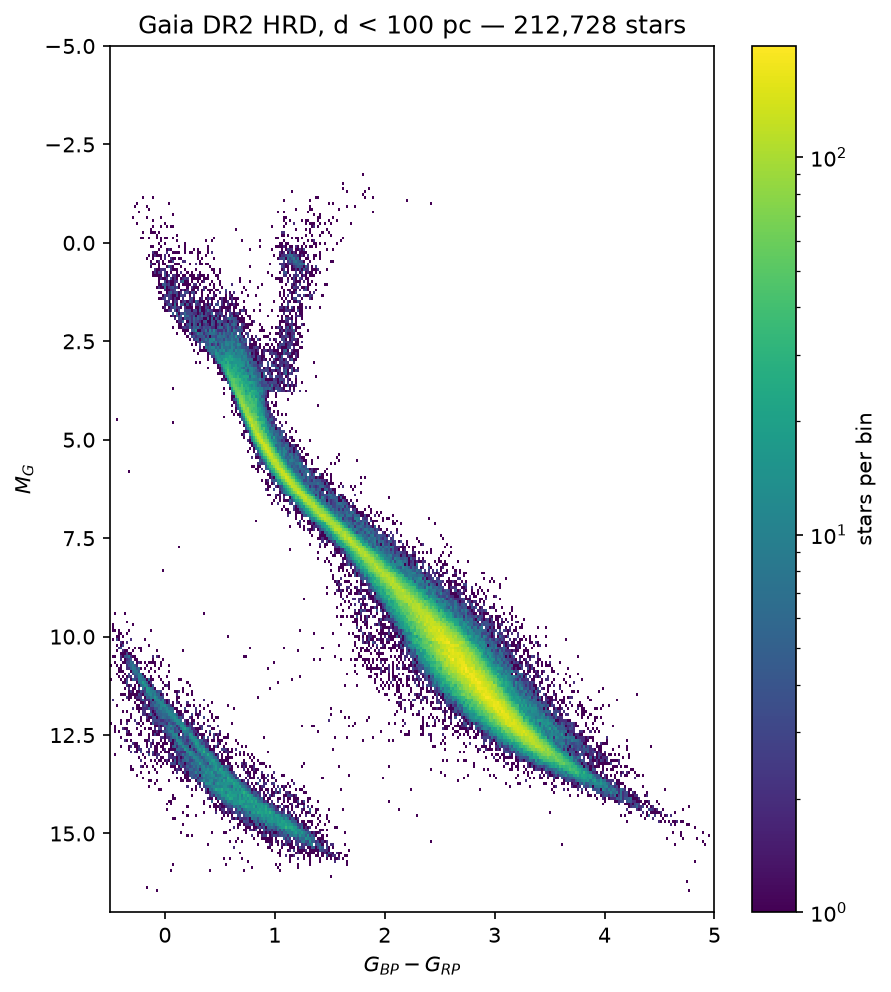

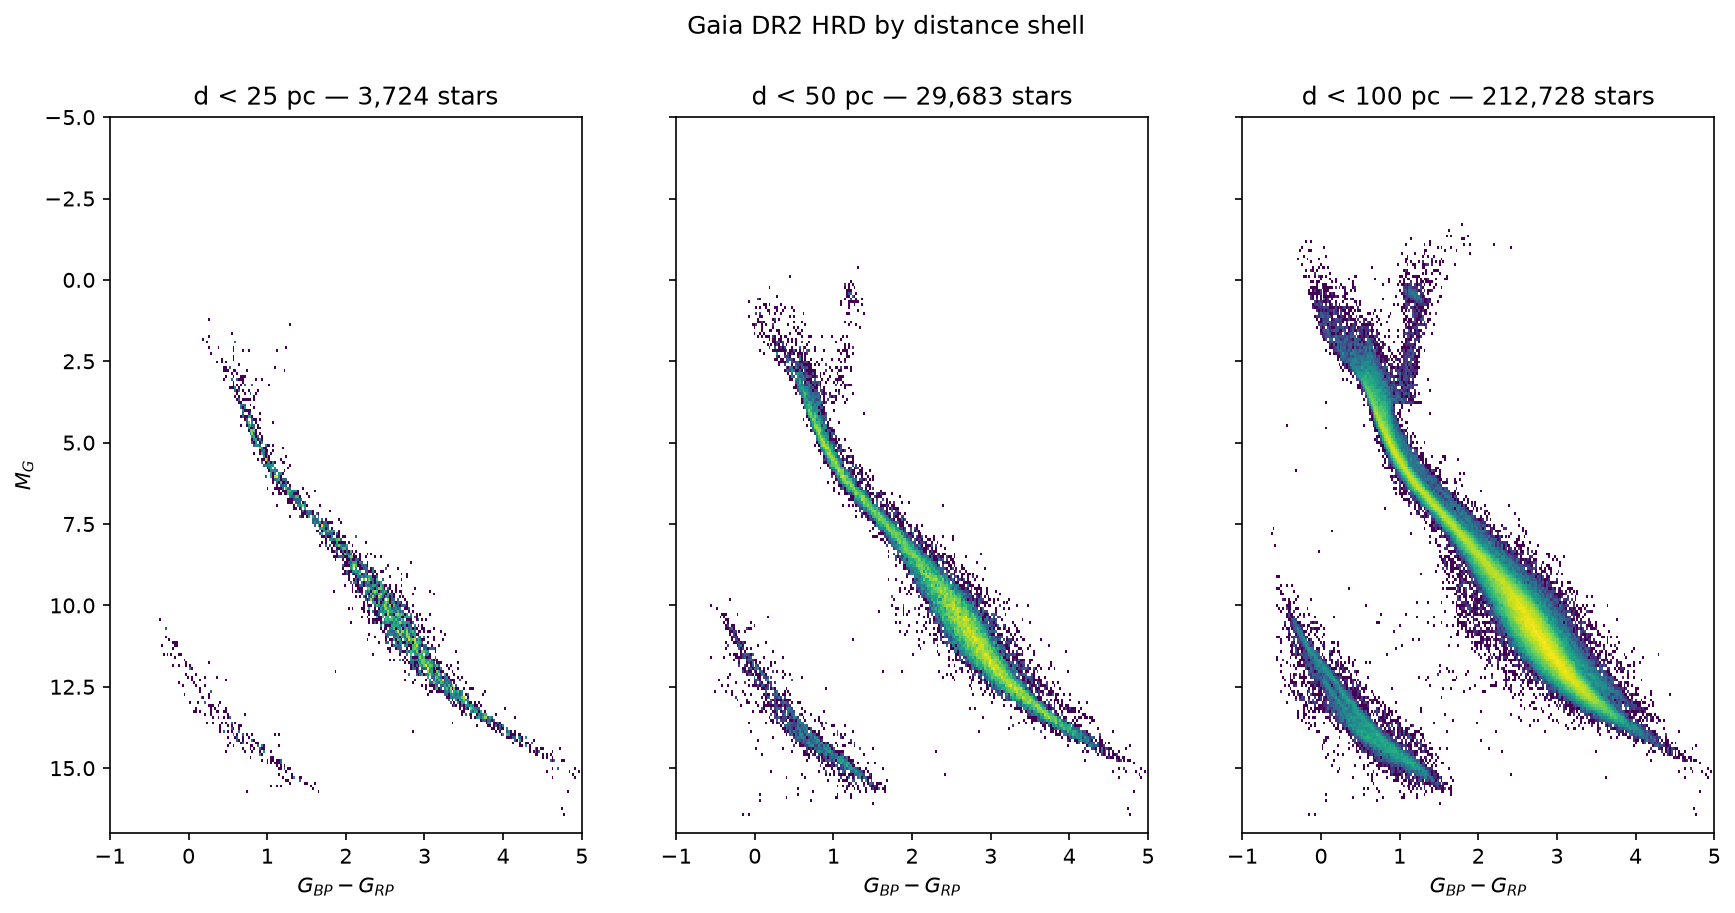

In [5]:
from IPython.display import Image, display

display(Image(f"{OUTPUT_DIR}/gaia_cmd_hrd.png", width=520))
display(Image(f"{OUTPUT_DIR}/gaia_cmd_shells.png", width=900))

## Deliverables, checked

| mini-project asks for | where it landed |
|---|---|
| density CMD in absolute magnitude | `gaia_cmd_hrd.png` — log-density, $M_G$ vs $G_{BP}-G_{RP}$, bright end up |
| quality filters + one-line justification each | the agent's report above (from the filter tool's metadata) |
| comparison with the published figure, incl. star counts | axes matched to Fig. 5c ($-1<BP\!-\!RP<5$, $17>M_G>-5$) and the filtered count vs **212,728** |

The four features to identify: the **main sequence**, the **binary
sequence** running parallel ~0.75 mag above it (unresolved equal pairs are
twice as bright), the **red clump** of core-helium-burning giants near
$BP\!-\!RP\approx1.2,\ M_G\approx0.5$, and the **white dwarf sequence** in
the lower left.

## Questions to think about — answered

**Why is inverting the parallax unsafe in general, and acceptable at
100 pc?** Parallax errors are symmetric, but $1/\varpi$ is not: for noisy
parallaxes the inferred distances are biased long, and a negative parallax —
perfectly legitimate as a *measurement* — has no inverse at all. Inversion
breaks roughly where $\sigma_\varpi/\varpi \gtrsim 20\%$; with DR2's
typical $\sigma_\varpi \approx 0.03$–$0.1$ mas that is a few hundred pc,
beyond which proper distance inference (e.g. Bailer-Jones et al. 2018) is
required. This sample demands $\varpi \ge 10$ mas *and*
$\varpi/\sigma_\varpi > 10$, so distances are good to $\lesssim 10\%$ and
the inversion bias is negligible.

**How does a parallax-SNR cut bias the sample?** At a fixed distance,
$\sigma_\varpi$ grows for fainter stars — so an SNR threshold is
effectively a magnitude cut in disguise. It preferentially removes the
intrinsically faint red end (late M dwarfs, cool white dwarfs): the sample
gets *better distances* but is no longer a fair census of the volume.
Dropping the SNR cut here grows the raw sample from ~439k to ~700k sources —
the difference is not random.

**Which parts of the diagram are incomplete?** The sample is volume-limited
in parallax but magnitude-limited in $G$ (DR2 fades out around
$G \approx 20.7$). At 100 pc that means complete only to
$M_G \approx 15.7$: the bottom of the main sequence and the cool end of the
white dwarf sequence are missing. The distance-shell figure shows it
directly — the 25 pc panel reaches visibly fainter $M_G$ than the 100 pc
panel, with a small fraction of the stars.

## Verification pass — how the pipeline holds up

- **Parallax inversion**: `compute_absolute_magnitudes` refuses non-positive
  parallaxes (reports how many it dropped) and its docstring states *why*
  inversion is legitimate only under the SNR > 10 selection.
- **Silent truncation**: the ADQL in `fetch_gaia_sample` has no `TOP` — the
  tool metadata returns the exact query — and the docstring points to
  `random_index` for honest subsampling.
- **Missing quality flags**: the excess-factor cut removes the spurious
  plume of blends, and the unit-weight-error cut is the published DR2-era
  precursor of `RUWE < 1.4` (DR2's main table has no `ruwe` column).
  The server's `01_manual_pipeline.ipynb` shows the unfiltered diagram —
  plume included.
- **"Matches the published figure"**: matched axes *and* matched counts —
  the default filters land on **exactly 212,728** stars.

## Where next

- `02_demo_client.ipynb` — the same client on the power-spectrum server.
- `03_next_steps.ipynb` — skills, memory, follow-ups, backend switching.
- Mini-project N: copy either server repo, replace `tools/`, and this
  client drives it without modification.